In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import os
import pandas as pd

In [2]:
folders = ['V_.1_K_.1_allostery','V_1_K_.1_allostery','V_10_K_.1_allostery',
           'V_.1_K_1_allostery', 'V_1_K_1_allostery', 'V_10_K_1_allostery',
           'V_.1_K_10_allostery','V_1_K_10_allostery','V_10_K_10_allostery',]

/tmp/ipykernel_8370/1836090222.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.07,0.05,0.98,0.98])


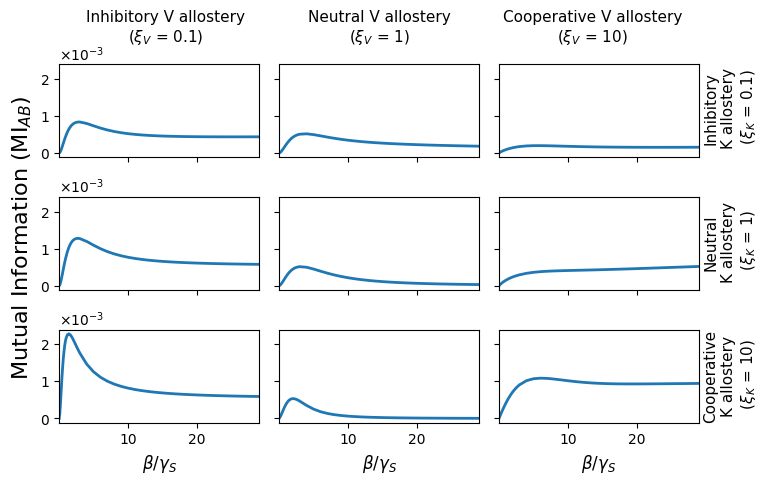

In [3]:
fig, axs = plt.subplots(3, 3, sharey=True, sharex=True, figsize=(8, 5.6))

# ---- Plot data into each axis ----
for folder, ax in zip(folders, axs.flatten()):
    beta, mi_allo, mi_nonallo = np.loadtxt(folder+'fcases/A_MI.csv').T

    ax.plot(beta, mi_allo, label='Allosteric', color='C0', linewidth=2)
    #ax.plot(beta, mi_nonallo, label='Non-allosteric', color='C1', linewidth=2)

    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_position((0, 1.01))


# =========================================================
#               COLUMN HEADERS (V ALLOSTERY)
# =========================================================
col_ax = fig.add_subplot(111, frameon=False)
col_ax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
col_ax.set_xticks([]); col_ax.set_yticks([])

labels = ['Inhibitory', 'Neutral', 'Cooperative']
xiV = ['0.1','1','10']

for i in range(3):
    col_ax.text((i+0.5)/3, 1.05,
                r'{} V allostery'.format(labels[i]) + '\n' +
                r'($\xi_V$ = {})'.format(xiV[i]),
                ha='center', va='bottom',
                fontsize=11, 
                transform=col_ax.transAxes)

# =========================================================
#               ROW HEADERS (K ALLOSTERY) — VERTICAL
# =========================================================
pos00 = axs[0,0].get_position()   # top-left
pos20 = axs[2,0].get_position()   # bottom-left
pos02 = axs[0,2].get_position()   # top-right

left   = pos00.x0
right  = pos02.x1
top    = pos00.y1
bottom = pos20.y0

rcol_box = [left, bottom, right - left, top - bottom]

row_ax = fig.add_axes(rcol_box, frameon=False)
row_ax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
row_ax.set_xticks([]); row_ax.set_yticks([])

xiK = ['0.1','1','10']
y_pos = [pos00.y1-.075, (pos00.y0 + pos20.y1)/2, pos20.y0+.075]
for i in range(3):
    row_ax.text(
        1.13,                             # move to the RIGHT of the right column
        y_pos[i],                # vertically center on each row
        r'{}'.format(labels[i]) + '\n' +
        r'K allostery'+ '\n' +
        r' ($\xi_K$ = {})'.format(xiK[i]),
        ha='center', va='center',
        rotation=90,
        fontsize=11,
        transform=row_ax.transAxes
    )

# --- Axis labels ---
for ax in axs[-1]:
    ax.set_xlabel(r'$\beta/\gamma_S$', fontsize=12)

    
fig.supylabel(r'Mutual Information ($\text{MI}_{AB}$)', fontsize=16, x=0.1, y=0.5)

fig.subplots_adjust(bottom=0.01)
axs[0,0].set_xlim(beta[0], beta[-1])
plt.tight_layout(rect=[0.07,0.05,0.98,0.98])

plt.savefig('f2', dpi=600, bbox_inches='tight')
plt.show()


In [4]:
folders = ['V_?_K_1_allostery','V_1_K_?_allostery','V_?_K_10_allostery','V_10_K_?_allostery']

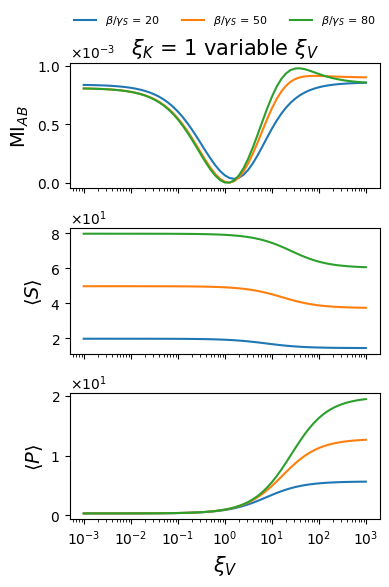

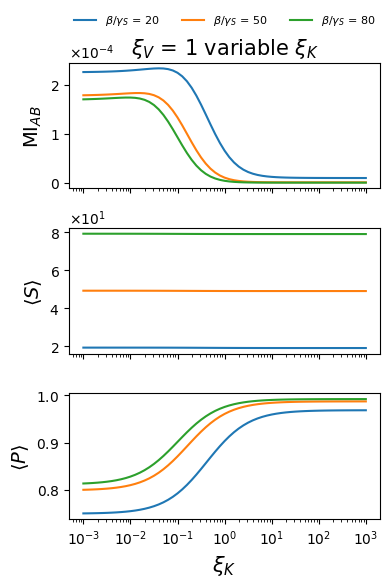

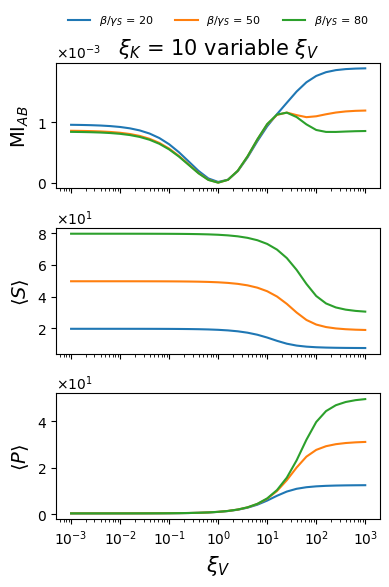

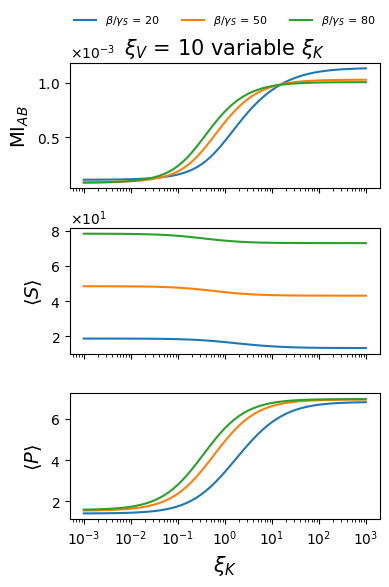

In [5]:
def plot_variable(folder,axs):
    betas, allos, MI, S, P = np.loadtxt(folder+'fcases/B_report.csv').T
    for b in [20,50,80]:
        axs[0].plot(allos[betas == b], MI[betas == b], label=rf'$\beta/\gamma_S$ = {int(b)}')
        axs[1].plot(allos[betas == b], S[betas == b])
        axs[2].plot(allos[betas == b], P[betas == b])

    # Log scale for last subplot's x-axis
    axs[2].set_xscale('log')
    axs[2].xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'$10^{{{int(np.log10(x))}}}$')
    )

for folder in folders:
    fig, axs = plt.subplots(3, 1, sharex=True,figsize=(4,6))
    plot_variable(folder,axs)
    

    # Legend outside on top
    axs[0].legend(
        loc='lower center',
        bbox_to_anchor=(0.5, 1.2),
        ncol=3,
        frameon=False,fontsize=8
    )

    # Scientific notation with offset text (outside axis)
    for ax in axs:
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax.yaxis.get_offset_text().set_position((0, 1.01))  # move exponent above axis
 
    _,vrate,_,krate,_ = folder.split('_')

    if vrate == '?':
        axs[-1].set_xlabel(r'$\xi_V$',fontsize=15)
        axs[0].set_title(r'$\xi_K$ = {} variable $\xi_V$'.format(krate),fontsize=15)
    else:
        axs[-1].set_xlabel(r'$\xi_K$',fontsize=15)
        axs[0].set_title(r'$\xi_V$ = {} variable $\xi_K$'.format(vrate),fontsize=15)

    [ax.set_ylabel(g,fontsize=14) for (ax,g) in zip (axs,[r'MI$_{AB}$',
                                            r'$\langle S \rangle$',
                                            r'$\langle P \rangle$',])]

    
    plt.tight_layout()
    #plt.show()
    plt.savefig(folder+'_B_report',bbox_inches='tight',dpi=600)


/tmp/ipykernel_8370/2410932334.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{t / factor:g}" for t in ticks])
/tmp/ipykernel_8370/2410932334.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{t / factor:g}" for t in ticks])
/tmp/ipykernel_8370/2410932334.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{t / factor:g}" for t in ticks])
/tmp/ipykernel_8370/2410932334.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{t / factor:g}" for t in ticks])
/tmp/ipykernel_8370/2410932334.py:41: UserWarning: set_ticklabels() should only be used with a fixed number 

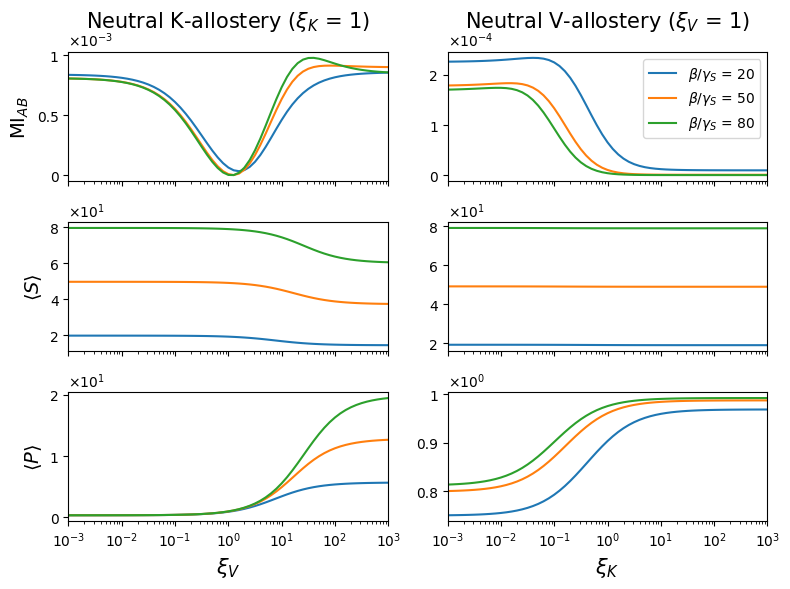

In [6]:
fig, axs = plt.subplots(3, 2, sharex=True, figsize=(8, 6))

for (folder, axi) in zip(folders[:2], axs.T):
    plot_variable(folder, axi)
    
    
# Titles and x-labels
axs[0, 0].set_title(r'Neutral K-allostery ($\xi_K$ = 1)', fontsize=15, pad=18)
axs[-1, 0].set_xlabel(r'$\xi_V$', fontsize=15)
axs[0, 1].set_title(r'Neutral V-allostery ($\xi_V$ = 1)', fontsize=15, pad=18)
axs[-1, 1].set_xlabel(r'$\xi_K$', fontsize=15)

# Y-labels on first column
for ax, g in zip(
    axs[:, 0],
    [r'MI$_{AB}$', r'$\langle S \rangle$', r'$\langle P \rangle$']
):
    ax.set_ylabel(g, fontsize=14)

# === Manual "×10^exp" style on all panels (including 10^0) ===
for ax in axs.flatten():
    ax.set_xlim(1e-3,1e3)
    ymin, ymax = ax.get_ylim()
    scale = max(abs(ymin), abs(ymax))
    if scale == 0:
        exp = 0
    else:
        exp = int(np.floor(np.log10(scale)))

    ticks = ax.get_yticks()
    if len(ticks) > 0:
        max_tick = max(abs(t) for t in ticks)
        # If everything is < 1 but exp==0, shift exponent down so we don't get 0.2, 0.4, ...
        if exp == 0 and max_tick < 1 and max_tick > 0:
            exp -= 1

    factor = 10**exp

    # Rescale tick labels
    ticks = ax.get_yticks()  # get again in case they changed
    ax.set_yticklabels([f"{t / factor:g}" for t in ticks])

    # Put ×10^exp above the axis
    ax.text(
        0.0, 1.02,
        rf"$\times 10^{{{exp}}}$",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
    )


# Legend (currently just on top-right axis; can switch to fig.legend if you want global)
axs[0, 1].legend()

fig.subplots_adjust(bottom=0.12)
plt.tight_layout()
plt.savefig('f3.png', dpi=600, bbox_inches='tight')


In [7]:
records = []

files = os.listdir("varallostery")
for file in files:
    try:
        _, v, k, beta, shape, times, _ = file.split("_")
        xi_v, xi_k = v.split("=")[-1], k.split("=")[-1]

        # remove trailing 'K' from xi_v
        xi_v = float(xi_v)
        xi_k = float(xi_k)
        try:
            times = float(times)
        except:
            times = times

        records.append({
            "xi_v": xi_v,
            "xi_k": xi_k,
            "shape": shape,
            "times": times,
            "beta": beta,
            "file": file
        })
    except ValueError:
        print(f"Skipping file (unexpected format): {file}")

# Convert to DataFrame
df = pd.DataFrame(records)

Skipping file (unexpected format): step_6_14_k=1_report.png
Skipping file (unexpected format): step_18_2_k=1_report.png
Skipping file (unexpected format): step_v=1_report.png
Skipping file (unexpected format): step_18_2_v=10_report.png
Skipping file (unexpected format): step_10_10_k=1_report.png
Skipping file (unexpected format): step_18_2_v=1_report.png
Skipping file (unexpected format): step_2_18_v=10_report.png
Skipping file (unexpected format): step_2_18_v=1_report.png
Skipping file (unexpected format): step_v=10_report.png
Skipping file (unexpected format): step_k=10_report.png
Skipping file (unexpected format): step_14_6_k=1_report.png
Skipping file (unexpected format): triangle_k=10_report.png
Skipping file (unexpected format): step_10_10_v=10_report.png
Skipping file (unexpected format): step_14_6_v=10_report.png
Skipping file (unexpected format): step_2_18_k=10_report.png
Skipping file (unexpected format): step_10_10_v=1_report.png
Skipping file (unexpected format): triangle_v

In [8]:
df

,xi_v,xi_k,shape,times,beta,file
0,1.00,10.0,varstep,[10. 10.],40,A_V=1.0_K=10.0_40_varstep_[10. 10.]_report.csv
1,10.00,20.0,varstep,[10. 10.],40,A_V=10.0_K=20.0_40_varstep_[10. 10.]_report.csv
2,1.00,20.0,triangle,10.0,40,A_V=1.0_K=20.0_40_triangle_10_report.csv
3,0.05,1.0,varstep,[10. 10.],40,A_V=0.05_K=1.0_40_varstep_[10. 10.]_report.csv
4,0.05,10.0,varstep,[14. 6.],40,A_V=0.05_K=10.0_40_varstep_[14. 6.]_report.csv
...,...,...,...,...,...,...
121,0.10,10.0,varstep,[10. 10.],40,A_V=0.1_K=10.0_40_varstep_[10. 10.]_report.csv
122,10.00,1.0,varstep,[14. 6.],40,A_V=10.0_K=1.0_40_varstep_[14. 6.]_report.csv
123,0.05,10.0,varstep,[ 2. 18.],40,A_V=0.05_K=10.0_40_varstep_[ 2. 18.]_report.csv
124,0.10,20.0,varstep,[18. 2.],40,A_V=0.1_K=20.0_40_varstep_[18. 2.]_report.csv


In [ ]:
def make_plot(df, axs,tmax =-1):
    for i, row in df.iterrows():
        file = row['file']
        xi_v = row['xi_v']
        xi_k = row['xi_k']
        #times = row['times']
        
        t,betas,S,P,MI = np.loadtxt('varallostery/'+file).T
        if tmax > 0:
            t,betas,S,P,MI = t[t<=tmax],betas[t<=tmax],S[t<=tmax],P[t<=tmax],MI[t<=tmax] 

        axs[0].plot(t, betas, linewidth = 5, color='k')
        axs[1].plot(t, MI)
        axs[2].plot(t,S)
        if np.all(df['xi_k'] == xi_k):
            #axs[0].set_title(r'$\xi_K$ = {} variable $\xi_V$'.format(xi_k),fontsize=15)
            axs[3].plot(t, P, label=rf'$\xi_V$ = {xi_v:.2f}')
        elif np.all(df['xi_v'] == xi_v):
            #axs[0].set_title(r'$\xi_V$ = {} variable $\xi_K$'.format(xi_v),fontsize=15)
            axs[3].plot(t, P, label=rf'$\xi_K$ = {xi_k:.2f}')

    axs[-1].set_xlim(t[0],t[-1])


    
def make_plot_single(df, title,tmax =-1):

    fig, axs = plt.subplots(4, 1, sharex=True,figsize=(4,8))
    make_plot(df, axs,tmax)

    [ax.set_ylabel(g,fontsize=14) for (ax,g) in zip (axs,[r'$\beta/\gamma_S$',
                                                          r'MI$_{AB}$',
                                                          r'$\langle S \rangle$',r'$\langle P \rangle$',])]
    if np.all(df['xi_k'] == df['xi_k'].to_numpy()[0]):
        axs[0].set_title(r'$\xi_K$ = {} variable $\xi_V$'.format(df['xi_k'].to_numpy()[0]),fontsize=15)
    elif np.all(df['xi_v'] == df['xi_v'].to_numpy()[0]):
        axs[0].set_title(r'$\xi_V$ = {} variable $\xi_K$'.format(df['xi_v'].to_numpy()[0]),fontsize=15)
    for ax in axs[1:]:
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax.yaxis.get_offset_text().set_position((0, 1.01))  # move exponent above axis

        ymin, ymax = ax.get_ylim()
        m = max(abs(ymin), abs(ymax))
        n = int(np.floor(np.log10(m)))

        if n>0:
            base = 3 * (10 ** n)      # 0, 3, 6 ... × 10^n
            ax.yaxis.set_major_locator(ticker.MultipleLocator(base=base))
            ax.set_ylim(0,np.ceil(m/10)*10)
    #axs[0].set_title(r'$\xi_k$ = 10 variable $\xi_V$',fontsize=15)
    axs[-1].set_xlabel(r'time',fontsize=15)
    fig.legend(
        loc='lower center',
        bbox_to_anchor=(0.5, .9),
        ncol=3,
        frameon=False,fontsize=8
    )
    fig.savefig('varallostery_'+title+'.png',bbox_inches='tight',dpi=600)

In [10]:
tri_k1  = df[(df["shape"]=="triangle") & (df["xi_k"]==1)  & df["xi_v"].isin([0.1,1,10])].sort_values("xi_v")
tri_k10 = df[(df["shape"]=="triangle") & (df["xi_k"]==10) & df["xi_v"].isin([0.1,1,10])].sort_values("xi_v")

tri_v1  = df[(df["shape"]=="triangle") & (df["xi_v"]==1)  & df["xi_k"].isin([0.1,1,10])].sort_values("xi_k")
tri_v10 = df[(df["shape"]=="triangle") & (df["xi_v"]==10) & df["xi_k"].isin([0.1,1,10])].sort_values("xi_k")


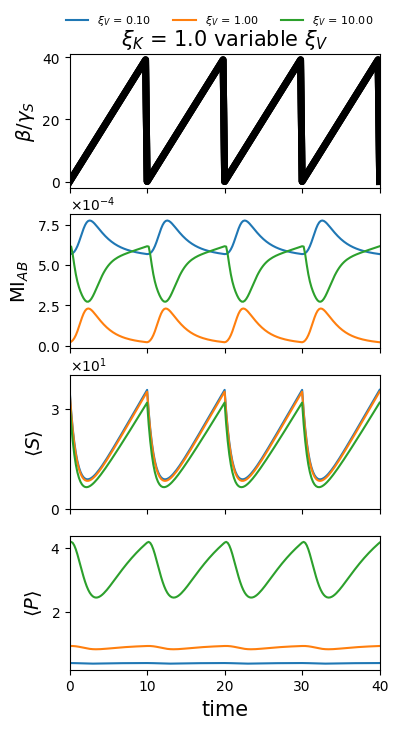

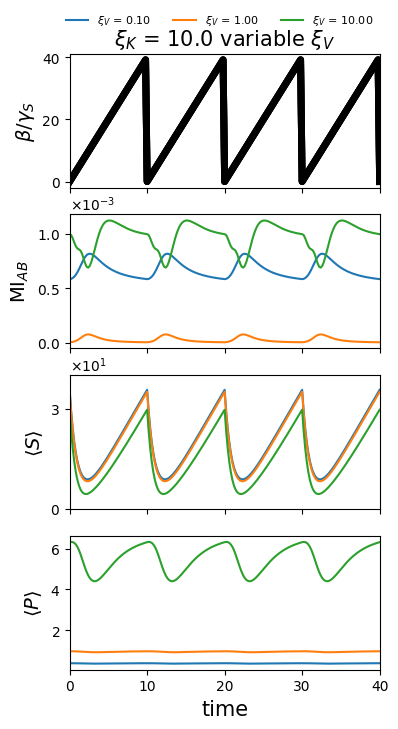

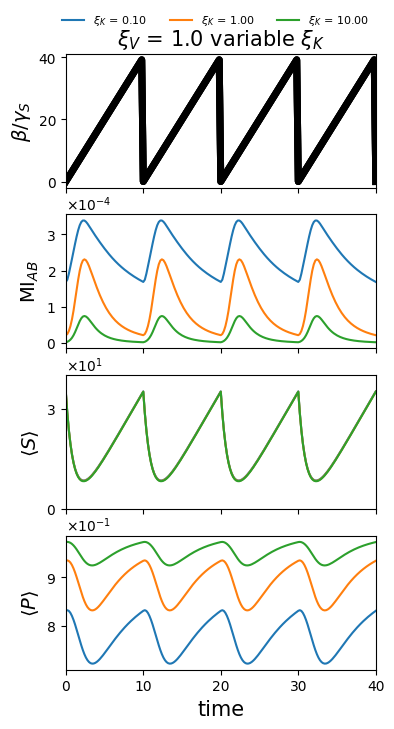

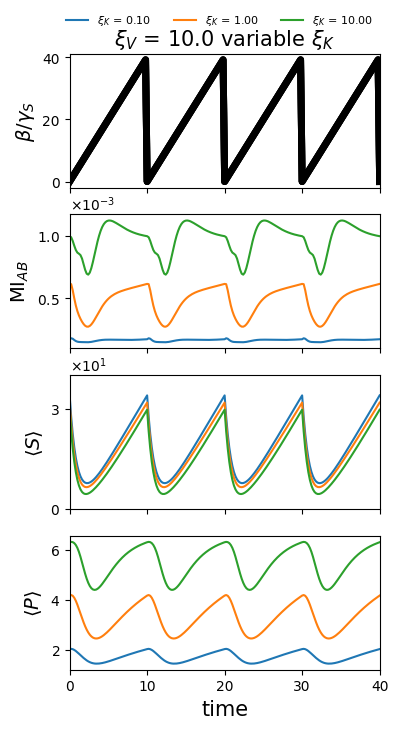

In [11]:
make_plot_single(tri_k1, 'triangle_k=1_report',tmax=40)
make_plot_single(tri_k10,'triangle_k=10_report',tmax=40)
make_plot_single(tri_v1, 'triangle_v=1_report_v',tmax=40)
make_plot_single(tri_v10,'triangle_v=10_report_v',tmax=40)


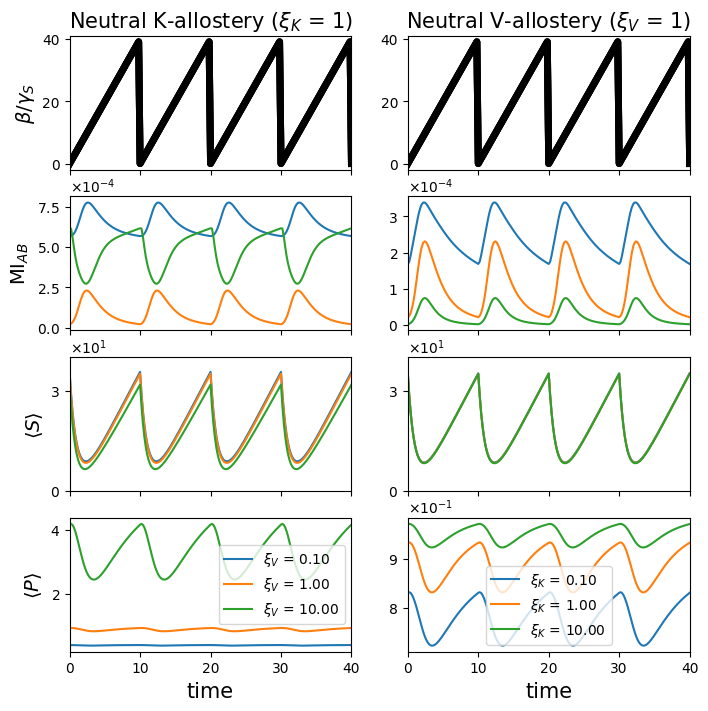

In [12]:
fig, axs = plt.subplots(4, 2, sharex=True,figsize=(8,8))

for (df, axi) in zip([tri_k1, tri_v1], axs.T):
    make_plot(df, axi,tmax=40)

[ax.set_ylabel(g,fontsize=14) for (ax,g) in zip (axs.T[0],[r'$\beta/\gamma_S$',
                                                           r'MI$_{AB}$',
                                                           r'$\langle S \rangle$',
                                                           r'$\langle P \rangle$',])]
axs[0,0].set_title(r'Neutral K-allostery ($\xi_K$ = 1)',fontsize=15)
axs[0,1].set_title(r'Neutral V-allostery ($\xi_V$ = 1)'.format(xi_v),fontsize=15)
for ax in axs[1:].flatten():
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_position((0, 1.01))  # move exponent above axis

    ymin, ymax = ax.get_ylim()
    m = max(abs(ymin), abs(ymax))
    n = int(np.floor(np.log10(m)))

    if n>0:
        base = 3 * (10 ** n)      # 0, 3, 6 ... × 10^n
        ax.yaxis.set_major_locator(ticker.MultipleLocator(base=base))
        ax.set_ylim(0,np.ceil(m/10)*10)
    #axs[0].set_title(r'$\xi_k$ = 10 variable $\xi_V$',fontsize=15)
[axi.set_xlabel(r'time',fontsize=15) for axi in axs[-1]]

[axi.legend() for axi in axs[-1]]

fig.savefig('f4.png',bbox_inches='tight',dpi=600)
    

In [13]:
df = pd.DataFrame(records)
step_k1  = df[(df['shape']=='varstep') & (df['times']=='[14.  6.]') & (df['xi_k']==1)  & df['xi_v'].isin([0.1, 1, 10])].sort_values('xi_v')
step_k10 = df[(df['shape']=='varstep') & (df['times']=='[14.  6.]') & (df['xi_k']==10) & df['xi_v'].isin([0.1, 1, 10])].sort_values('xi_v')

step_v1  = df[(df['shape']=='varstep') & (df['times']=='[14.  6.]') & (df['xi_v']==1)  & df['xi_k'].isin([0.1, 1, 10])].sort_values('xi_k')
step_v10 = df[(df['shape']=='varstep') & (df['times']=='[14.  6.]') & (df['xi_v']==10) & df['xi_k'].isin([0.1, 1, 10])].sort_values('xi_k')


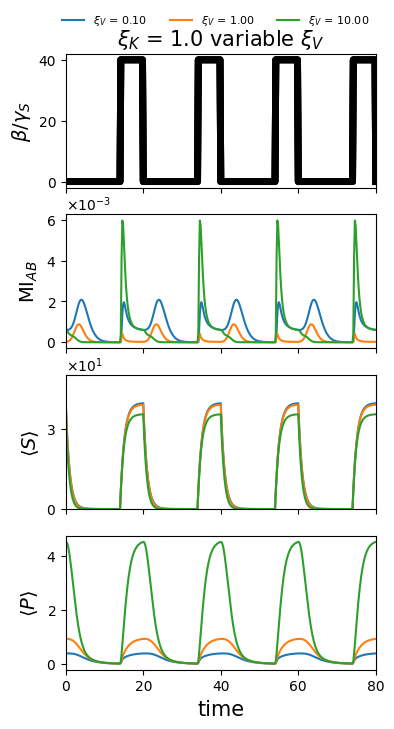

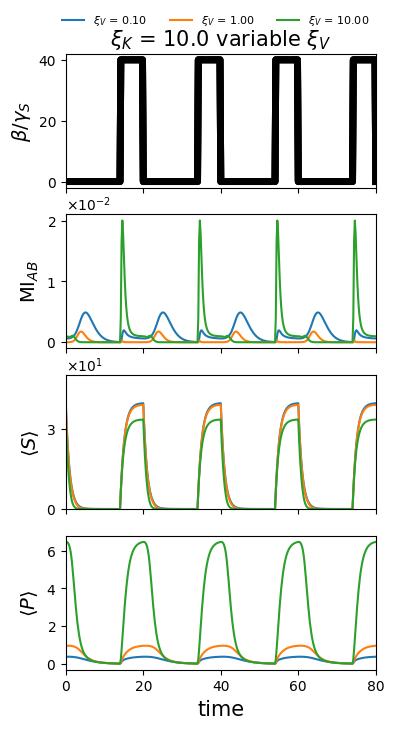

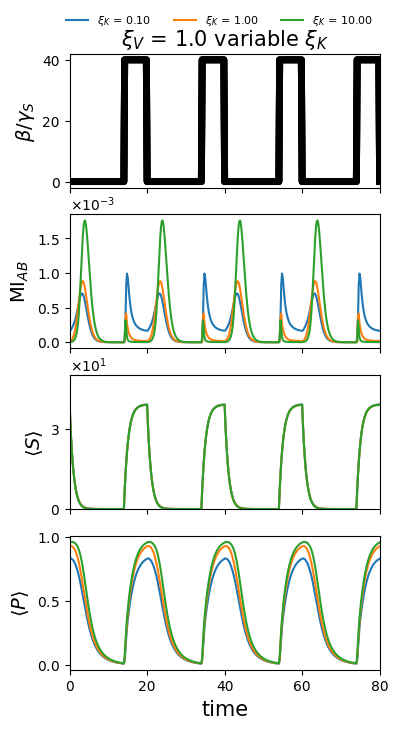

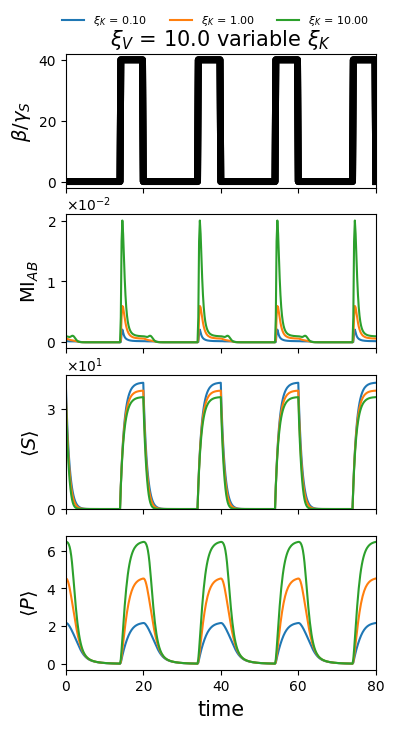

In [14]:
make_plot_single(step_k1, 'step_k=1_report_14_6')
make_plot_single(step_k10,'step_k=10_report_14_6')
make_plot_single(step_v1, 'step_v=1_report_14_6')
make_plot_single(step_v10,'step_v=10_report_14_6')

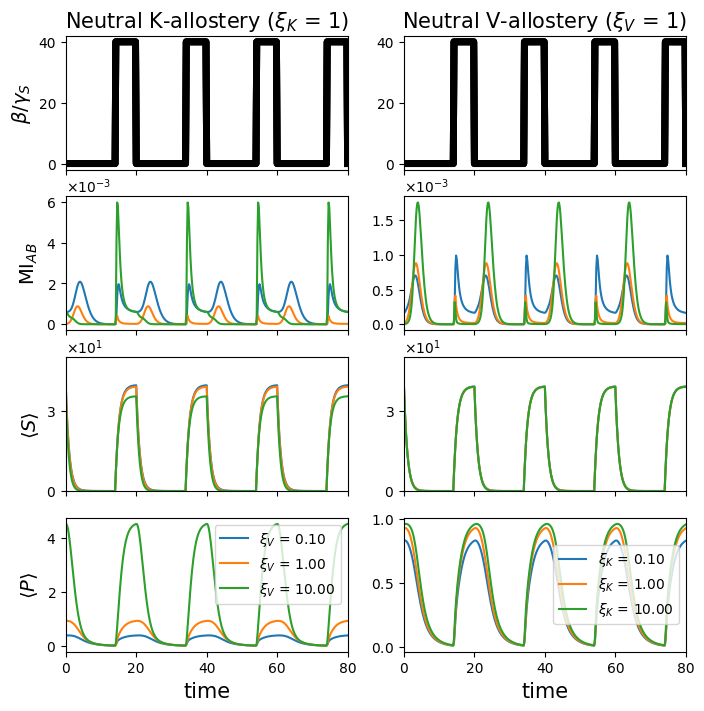

In [15]:
fig, axs = plt.subplots(4, 2, sharex=True,figsize=(8,8))

for (df, axi) in zip([step_k1, step_v1], axs.T):
    make_plot(df, axi)

[ax.set_ylabel(g,fontsize=14) for (ax,g) in zip (axs.T[0],[r'$\beta/\gamma_S$',
                                                           r'MI$_{AB}$',
                                                           r'$\langle S \rangle$',
                                                           r'$\langle P \rangle$',])]
axs[0,0].set_title(r'Neutral K-allostery ($\xi_K$ = 1)',fontsize=15)
axs[0,1].set_title(r'Neutral V-allostery ($\xi_V$ = 1)'.format(xi_v),fontsize=15)
for ax in axs[1:].flatten():
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_position((0, 1.01))  # move exponent above axis

    ymin, ymax = ax.get_ylim()
    m = max(abs(ymin), abs(ymax))
    n = int(np.floor(np.log10(m)))

    if n>0:
        base = 3 * (10 ** n)      # 0, 3, 6 ... × 10^n
        ax.yaxis.set_major_locator(ticker.MultipleLocator(base=base))
        ax.set_ylim(0,np.ceil(m/10)*10)
    #axs[0].set_title(r'$\xi_k$ = 10 variable $\xi_V$',fontsize=15)
[axi.set_xlabel(r'time',fontsize=15) for axi in axs[-1]]

[axi.legend() for axi in axs[-1]]

fig.savefig('f4_alternative.png',bbox_inches='tight',dpi=600)
    

In [16]:
step_k1  = df[(df['shape']=='varstep') & (df['times']=='[10. 10.]') & (df['xi_k']==1)  & df['xi_v'].isin([0.1,1,10])].sort_values('xi_v')
step_k10 = df[(df['shape']=='varstep') & (df['times']=='[10. 10.]') & (df['xi_k']==10) & df['xi_v'].isin([0.1,1,10])].sort_values('xi_v')

step_v1  = df[(df['shape']=='varstep') & (df['times']=='[10. 10.]') & (df['xi_v']==1)  & df['xi_k'].isin([0.1,1,10])].sort_values('xi_k')
step_v10 = df[(df['shape']=='varstep') & (df['times']=='[10. 10.]') & (df['xi_v']==10) & df['xi_k'].isin([0.1,1,10])].sort_values('xi_k')


UnboundLocalError: cannot access local variable 't' where it is not associated with a value

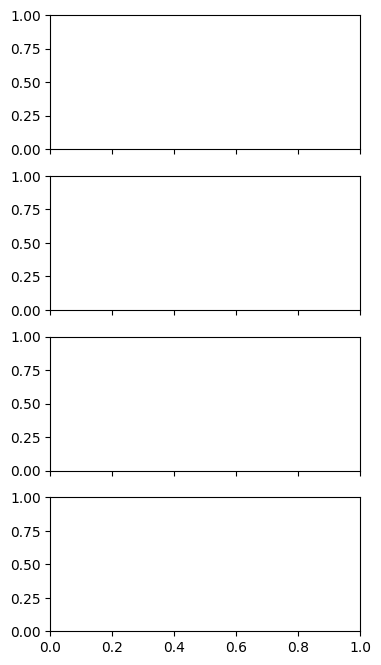

In [17]:
make_plot_single(step_k1, 'step_k=1_report_10_10')
make_plot_single(step_k10,'step_k=10_report_10_10')
make_plot_single(step_v1, 'step_v=1_report_10_10')
make_plot_single(step_v10,'step_v=10_report_10_10')